In [2]:
%load_ext autoreload
%autoreload 2

In [3]:

import sys
import os

# Explicitly point to the notebooks folder
notebook_dir = os.path.join(os.getcwd(), 'notebooks')
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

from helpers import *




## Trackline Detection via Radon Transform

This notebook detects and extracts individual **survey tracklines** from a bathymetric raster by exploiting the linear spatial structure left by vessel survey passes.

**Overall pipeline:**

1. Load the BAG raster and build a binary coverage mask.
2. *(Optional)* Apply morphological filtering to suppress blob-like dense coverage patches, leaving only thin linear trackline structures.
3. Skeletonise the filtered image to single-pixel-width lines.
4. Use the **Radon transform** to identify the dominant line orientations (angles).
5. Iteratively extract line families: for each dominant angle, run a Hough line transform, build a band mask, and peel off that family from the skeleton.
6. For each extracted family, assign real depth values, rotate into a trackline-aligned frame, and cluster individual lines with DBSCAN.

### 1. Load Bathymetric Data

Load the BAG (Bathymetric Attributed Grid) raster file. The result is a dict containing the raw 2D depth array and metadata (geotransform, resolution, no-data value). No-data values are **not** masked on load — they are handled explicitly in subsequent steps.

c:\Users\personal\miniconda3\envs\interpolation_uncertainty\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


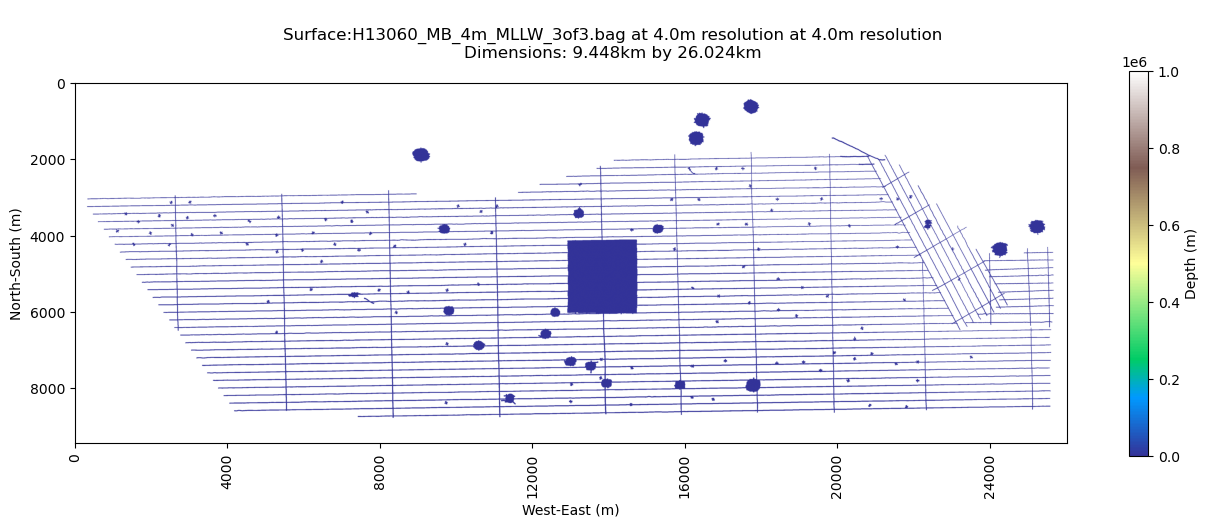

In [21]:
fn = r"data/raster/H13060_MB_4m_MLLW_3of3.bag"
bathy_data = read_file(fn)
show_depth(bathy_data)

### 2. Create Binary Mask from Valid Depth Data

Replace no-data values with zero and build a binary mask where `1` = valid sounding, `0` = no-data. This mask drives all subsequent morphological and line-detection steps — the spatial pattern of coverage gaps is what reveals the survey tracklines.

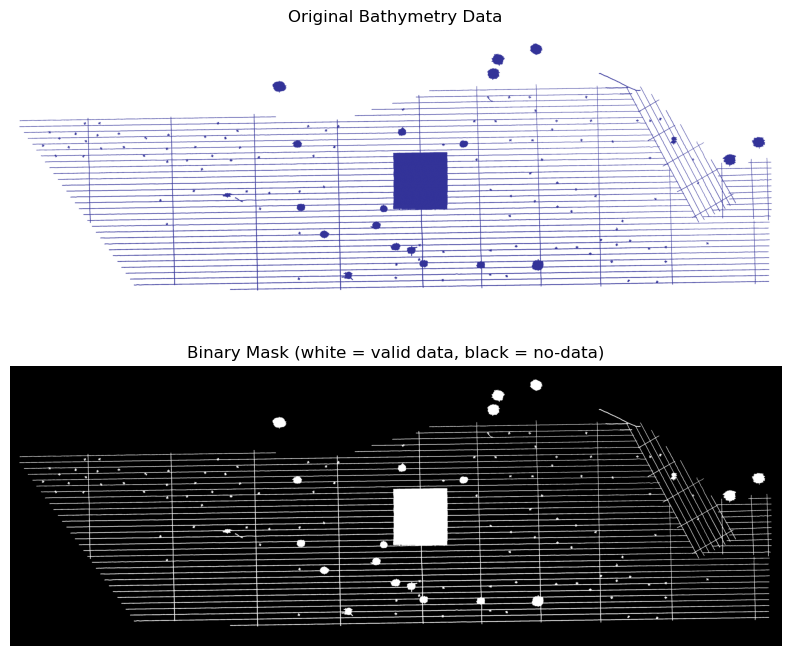

In [ ]:
new_bathy_data = deepcopy(bathy_data)
new_bathy_data['data'] = np.where(new_bathy_data['data'] == new_bathy_data['metadata']['ndv_value'], 
                                  np.nan, new_bathy_data['data'])

# Build a binary mask: 1 where valid depth data exists, 0 where no-data
bathy_binary = np.zeros_like(new_bathy_data['data'], dtype=bool)
bathy_binary[~np.isnan(new_bathy_data['data'])] = 1

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.imshow(bathy_data['data'], cmap='terrain')
plt.title('Original Bathymetry Data')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(bathy_binary, cmap='gray')
plt.title('Binary Mask (white = valid data, black = no-data)')
plt.axis('off')
plt.show()

### 3. (Optional) Extract Tracklines via Morphological Filtering

Apply a pipeline of directional morphological operations to suppress blob-like features (e.g., dense, uniformly surveyed patches) while preserving thin linear structures (survey tracklines).

Key parameters to tune:
- `line_length` — minimum length (pixels) a structure must have to survive as a "line"
- `square_size` — minimum side length (pixels) a structure must have to be removed as a "blob"
- `n_angles` — number of directions tested; more angles = finer detection but slower
- `restore_radius` — disk radius for restoring lines that were eroded in the cleanup process
- `blob_max_size` — maximum blob size to retain. blobs smaller than this size will be removed

In [23]:
morphological_output = filter_morphological_operations(bathy_binary, 
                                                       square_size=40, 
                                                       line_length=150, 
                                                       n_angles=90, 
                                                       restore_radius=3,
                                                       blob_max_size=100)

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.imshow(1 - bathy_binary, cmap='gray')
plt.title(f"Original Binary Image)")
plt.axis('off')
    
plt.subplot(2, 1, 2)
plt.imshow(1 - morphological_output, cmap='gray')
plt.title(f"Morphologically Filtered Image")
plt.axis('off')
plt.show()


  2%|▏         | 2/90 [00:11<08:18,  5.67s/it]


KeyboardInterrupt: 

### 4. Skeletonise the Filtered Lines

Reduce the filtered binary image to single-pixel-width lines. Three algorithms are compared side by side — choose the one that best preserves trackline connectivity for the Radon transform input.

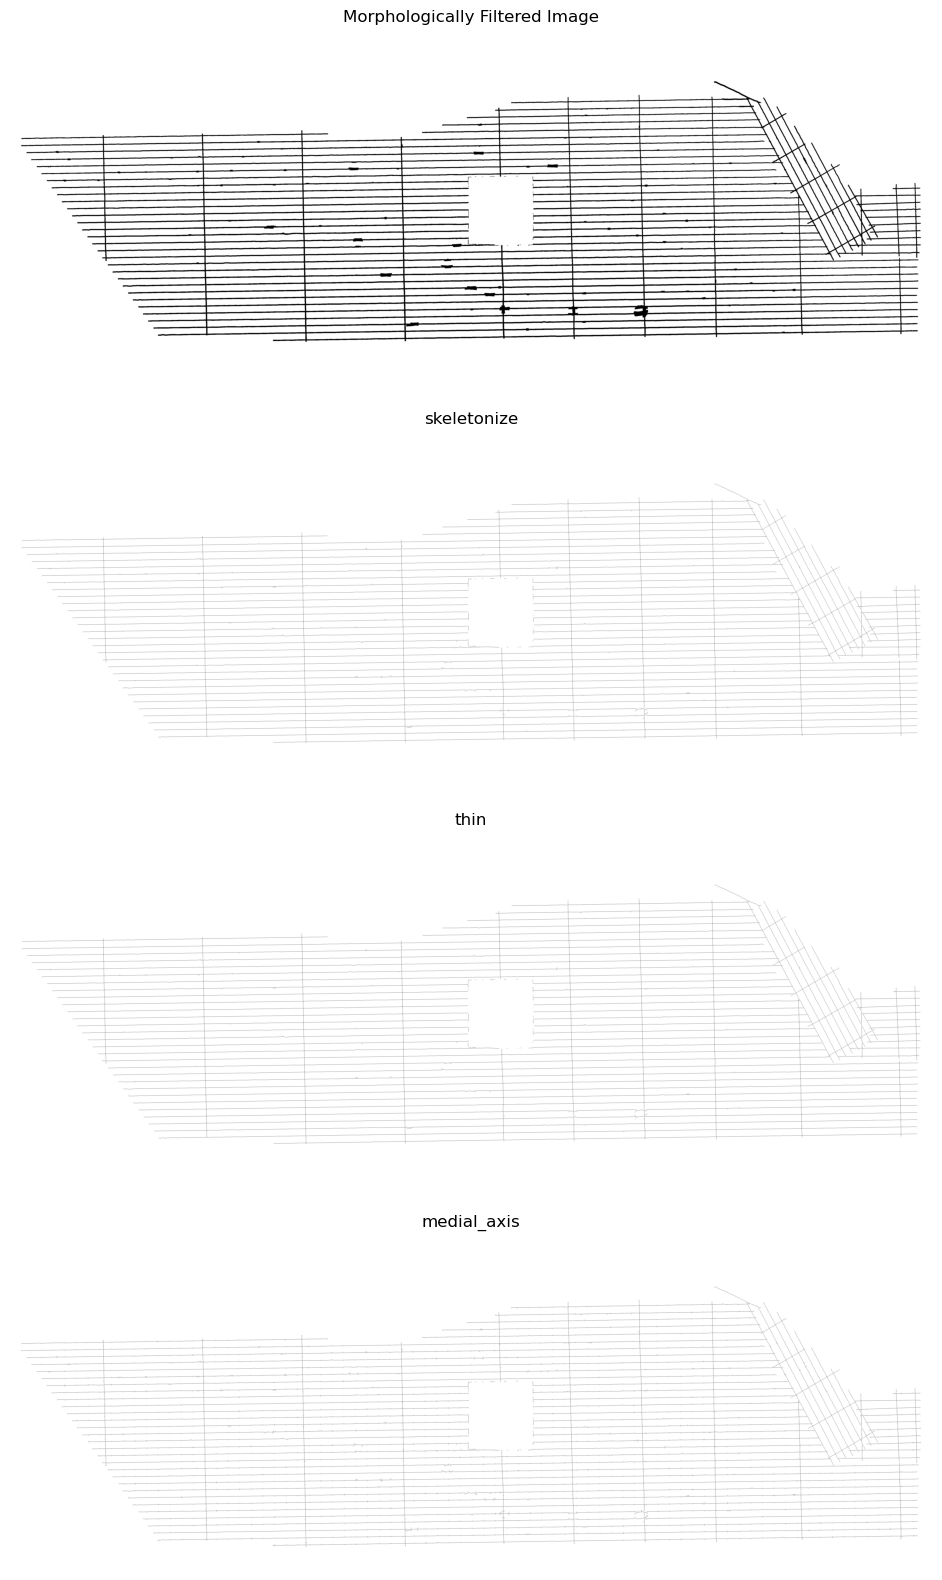

In [ ]:
# Reduce lines to single-pixel width using three thinning algorithms.
# Compare outputs visually to choose the best skeleton for this dataset:
#   skeletonize  — topology-preserving thinning via medial axis approximation
#   thin         — iterative pixel removal; tends to produce smoother skeletons
#   medial_axis  — exact medial axis transform; most sensitive to boundary noise
morphological_skeleton = skeletonize(morphological_output).astype(np.uint8)
morphological_thin     = thin(morphological_output).astype(np.uint8)
morphological_medial   = medial_axis(morphological_output).astype(np.uint8)

plt.figure(figsize=(15, 20))
plt.subplot(4, 1, 1)
plt.imshow(1 - morphological_output, cmap='gray')
plt.title('Morphologically Filtered Image')
plt.axis('off')
plt.subplot(4, 1, 2)
plt.imshow(1 - morphological_skeleton, cmap='gray')
plt.title('skeletonize')
plt.axis('off')
plt.subplot(4, 1, 3)
plt.imshow(1 - morphological_thin, cmap='gray')
plt.title('thin')
plt.axis('off')
plt.subplot(4, 1, 4)
plt.imshow(1 - morphological_medial, cmap='gray')
plt.title('medial_axis')
plt.axis('off')
plt.show()

In [ ]:
# Select the skeletonisation method that best preserves trackline connectivity
# based on the visual comparison above. Change the right-hand side to
# morphological_skeleton or morphological_medial if either looks cleaner.

# pre_skeleton = dilation(morphological_thin, disk(radius=5))
pre_skeleton = morphological_thin
final_skeleton = pre_skeleton.astype(bool).copy()

#### OPTIONAL: In case of near vertical lines, we can rotate the binary image slightly to improve numerical stability in line detection

In [ ]:
# # Rotate the binary skeleton to avoid near vertical lines, which cause issues for the Radon transform
# final_skeleton = rotate(final_skeleton, angle=20, resize=False, preserve_range=True).astype(bool)

(np.float64(-0.5), np.float64(6505.5), np.float64(2361.5), np.float64(-0.5))

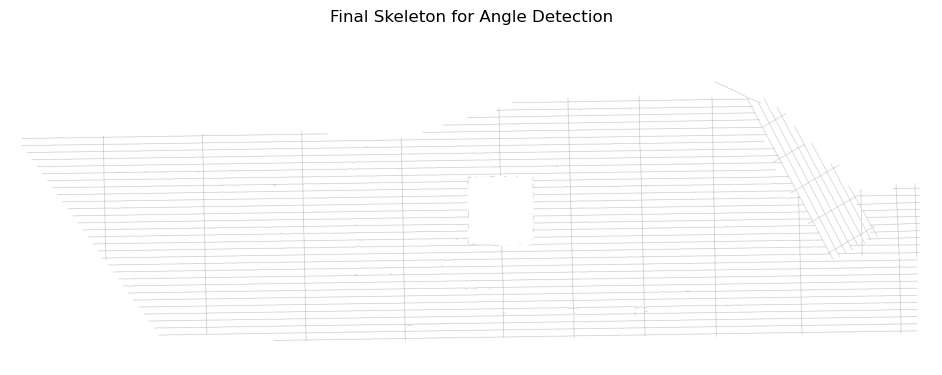

In [ ]:
# Visualise the final skeleton that will be used for angle detection
plt.figure(figsize=(15, 20))
plt.subplot(4, 1, 1)
plt.imshow(1 - final_skeleton, cmap='gray')
plt.title('Final Skeleton for Angle Detection')
plt.axis('off')

### 5. Detect Dominant Line Orientations via Radon Transform

The Radon transform projects the skeleton image along each tested angle. The **variance** of each projection column peaks when lines in the image are perpendicular to the projection direction — i.e., when projections are highly concentrated. The angle with maximum variance is the dominant trackline orientation.

Detected peaks at angles: [ 91. 118.   1.] with properties: {'prominences': array([ 249.31123115,  137.88158894, 7257.39518946]), 'left_bases': array([0, 8, 8]), 'right_bases': array([  8,  30, 171])}


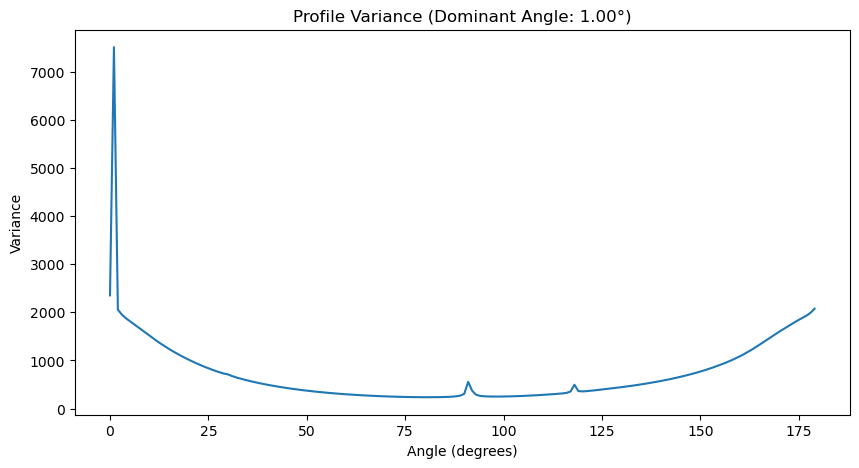

Most dominant angle: 1.0°


In [ ]:
# Run the Radon transform over the full skeleton to identify the single most
# prominent orientation. The variance profile peaks at angles where projections
# are concentrated — characteristic of linear features aligned with that angle.
dominant_angles, widths, _ = compute_dominant_angle_radon_transform(
    final_skeleton, plot_profile_variance=True, circle=False
)


print(f"Most dominant angle: {dominant_angles[0]:.1f}°")

In [ ]:
dominant_angles, widths

(array([  1,  91, 118]), array([1.36952966, 1.17709488, 1.01421958]))

### 6. Iteratively Extract Line Families

Repeat the following `num_line_families` times, each time working on the skeleton remaining after the previous family has been removed:

1. **Radon** → find the dominant angle in the remaining skeleton (suppressing already-extracted angles).
2. **Hough** → detect specific line positions within a narrow angular band around that dominant angle.
3. **Band mask** → mark all skeleton pixels within `band_width` pixels of any detected Hough line.
4. **Subtract** → remove the masked family from the working skeleton and repeat.

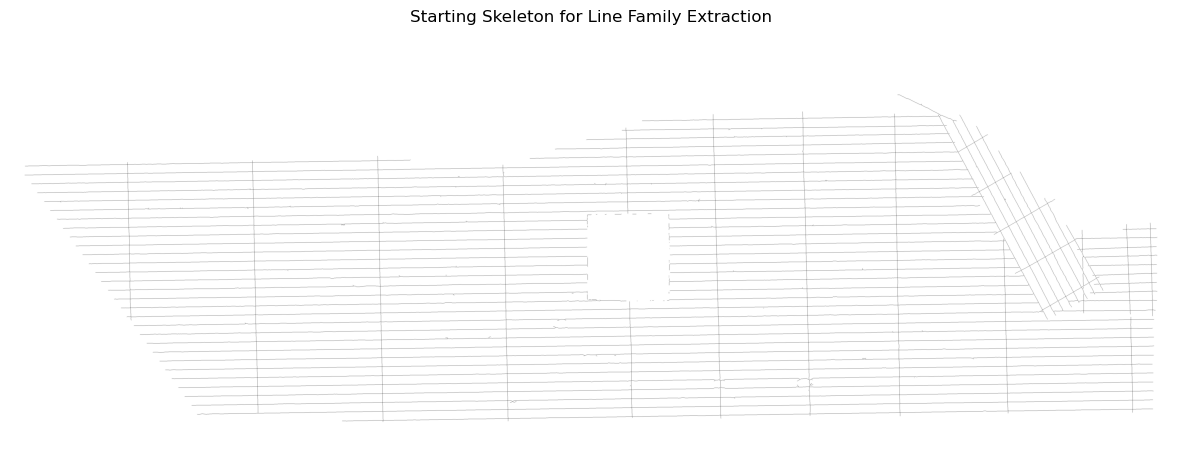

  0%|          | 0/3 [00:00<?, ?it/s]

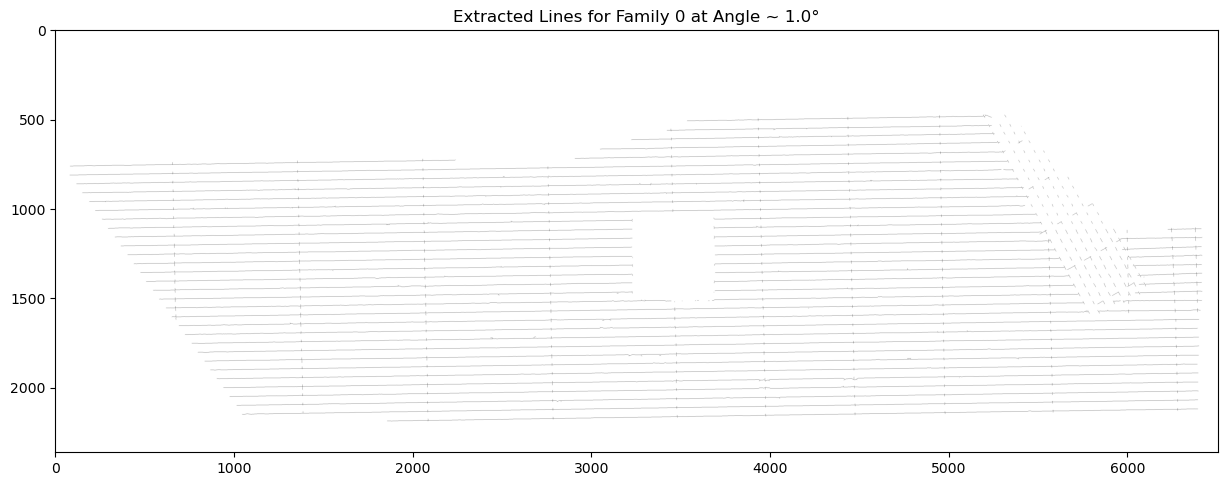

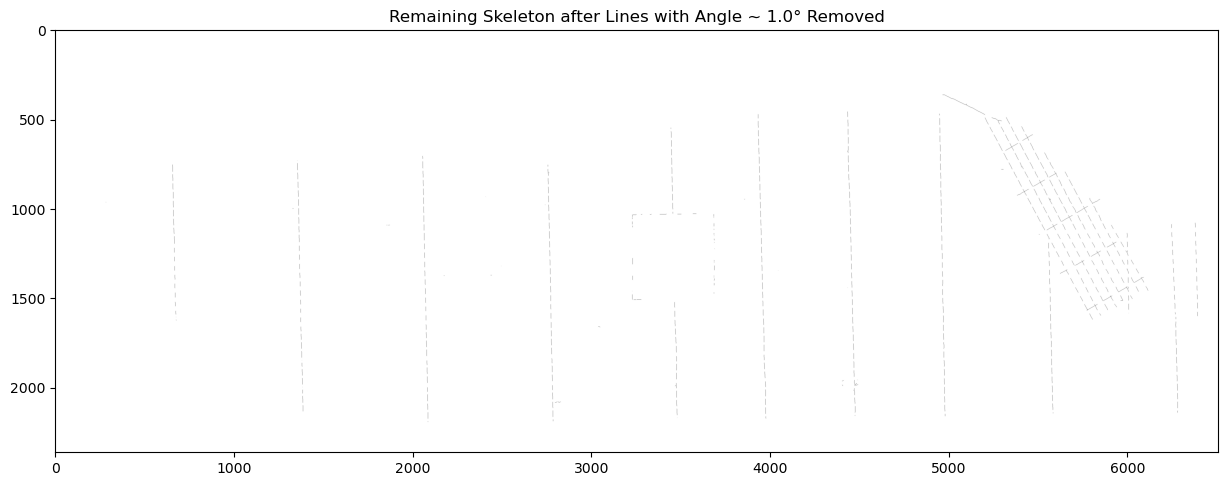

100%|██████████| 2015/2015 [00:09<00:00, 203.27it/s]


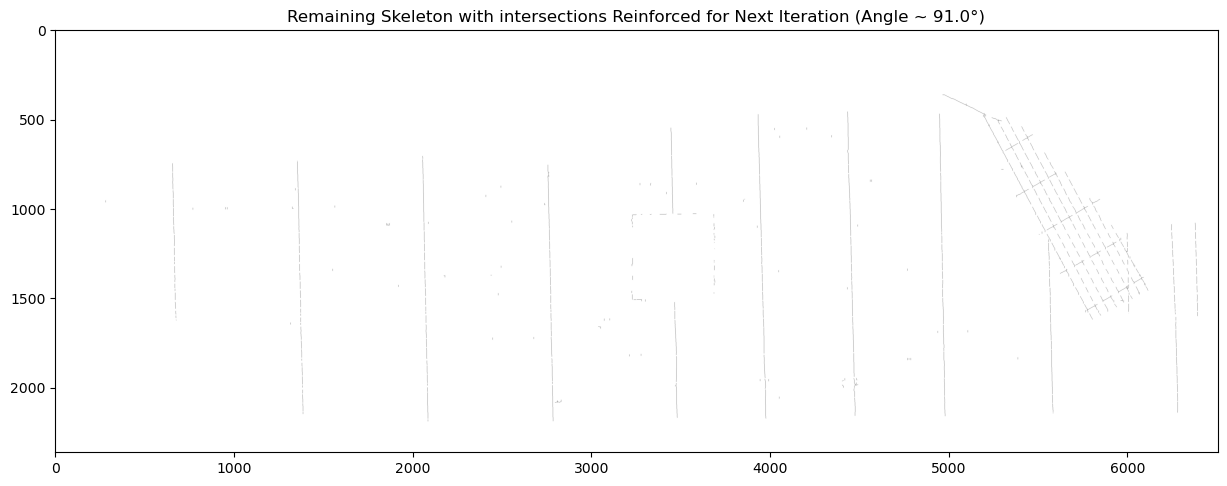

 33%|███▎      | 1/3 [00:27<00:54, 27.16s/it]

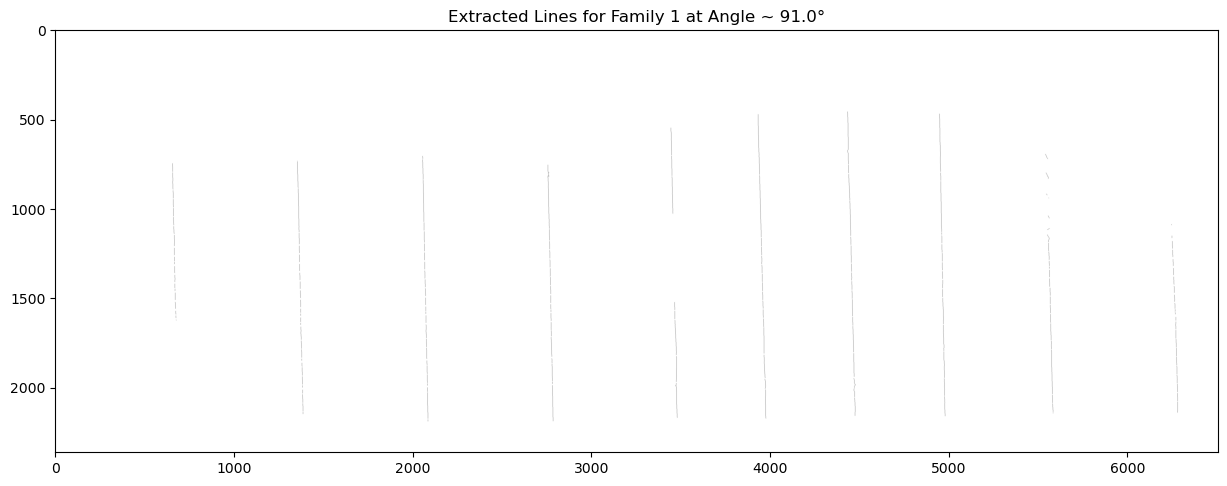

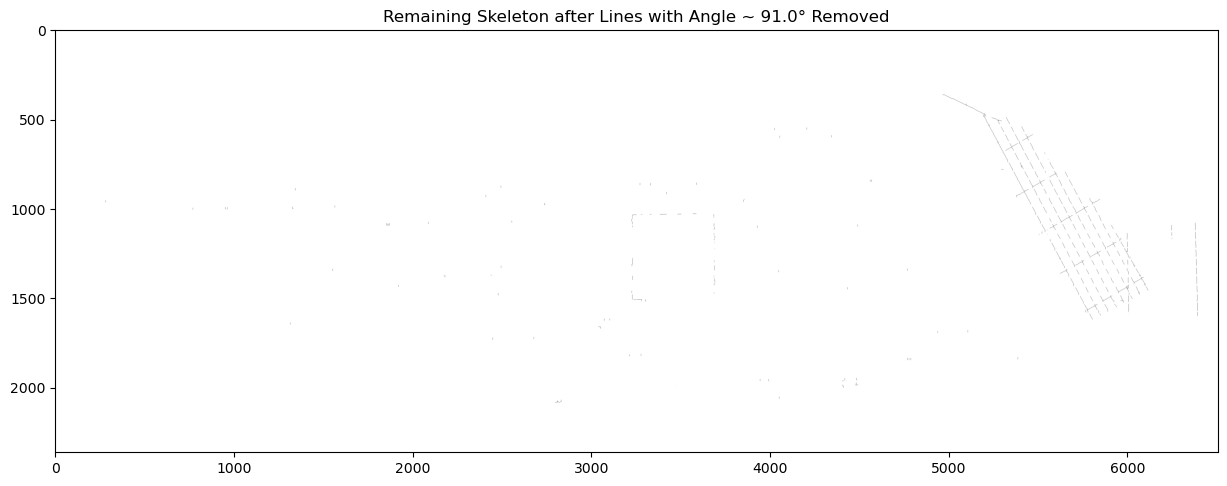

100%|██████████| 138/138 [00:00<00:00, 206.30it/s]


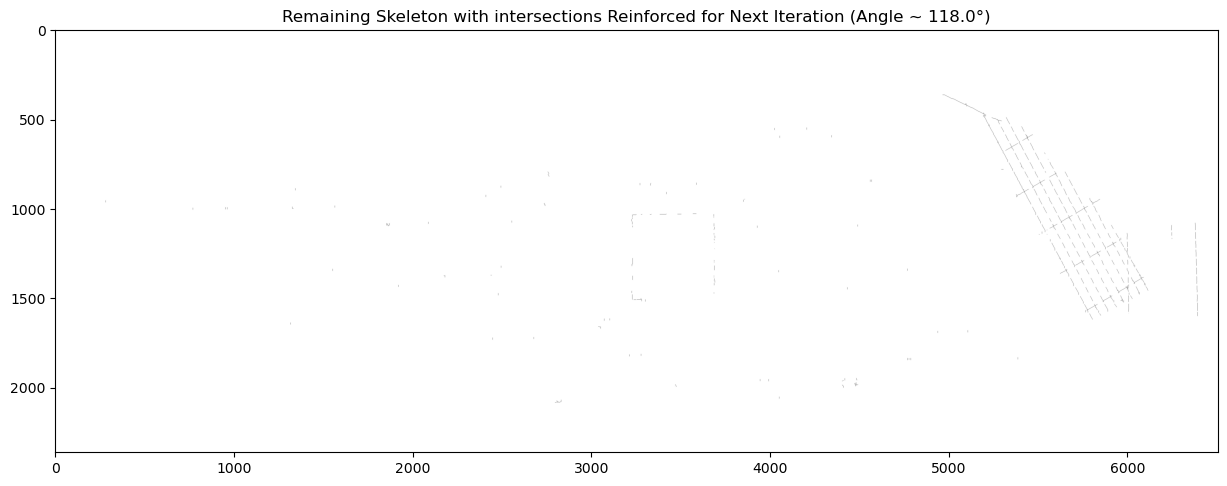

 67%|██████▋   | 2/3 [00:36<00:16, 16.90s/it]

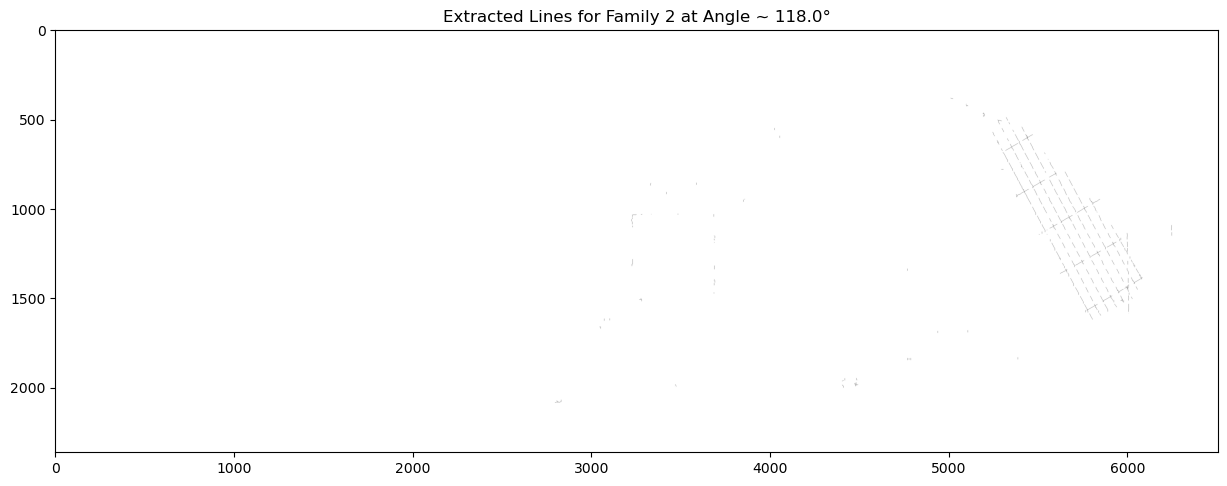

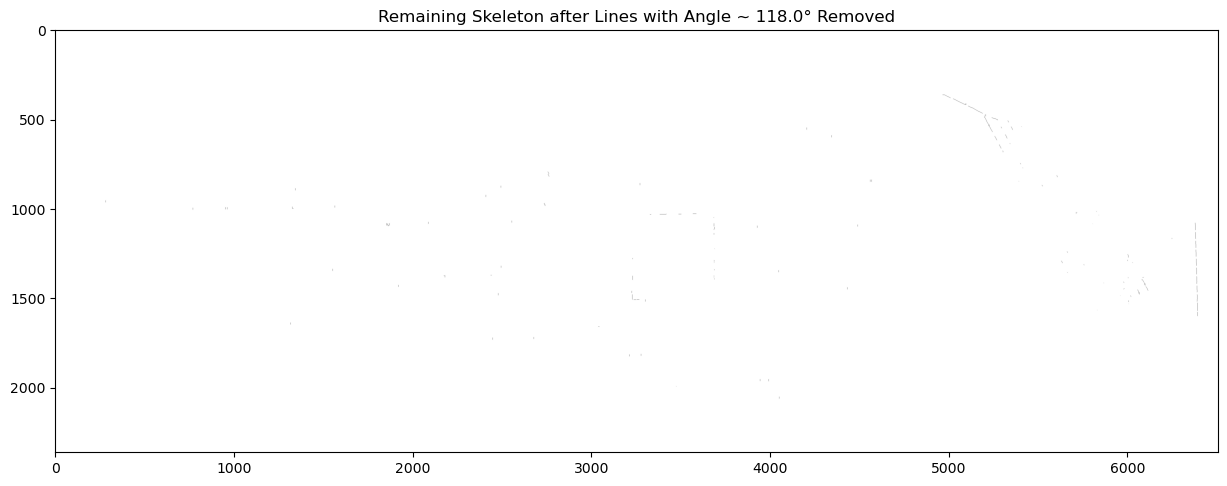

100%|██████████| 3/3 [02:12<00:00, 44.21s/it]


In [5]:
num_line_families = 3   # Expected number of distinct trackline orientations
# angular_tolerance = 10  # Degrees; Hough search window half-width around each dominant angle


current_binary = final_skeleton.copy()
plt.figure(figsize=(15, 13))
plt.imshow(1 - current_binary, cmap='gray')
plt.title('Starting Skeleton for Line Family Extraction')
plt.axis('off')
plt.show()

line_dicts = {}

dominant_angles_rad = np.deg2rad(dominant_angles)

 # Pixel half-width of the extraction band around each detected Hough line
bandwidth_pixels = 14                   

# For the search window, use the minimum angle difference between detected dominant angles 
# Subtract a small margin (e.g., 1 degree) to ensure distinct separation.
angle_search_window = int(np.floor(np.min(np.diff(dominant_angles))) - 1) // 2
tol = np.deg2rad(angle_search_window)   

# List of intersection points
intersection_pts = detect_intersections(current_binary.astype(bool))

# Iteratively extract line families detected from the Radon transform, starting with the most dominant. 
# Each iteration removes the extracted family from the working skeleton so the next operates only on unassigned lines.
for i in tqdm(range(num_line_families)):

    dominant_angle_rad = dominant_angles_rad[i]

    # STEP 1: Run the Hough line transform over a narrow band of angles centred
    # on the dominant angle, then detect peaks above the threshold.

    # Ensure the Hough search is perpendicular to the dominant angle to capture lines aligned with it
    shifted_angle_rad = (dominant_angle_rad + np.pi / 2) % np.pi

    # Create the search window around the shifted angle to capture lines aligned with the dominant angle
    start_angle_rad = shifted_angle_rad - tol
    end_angle_rad = shifted_angle_rad + tol
    rad_step = np.deg2rad(0.2)  # Finer angle resolution for better line detection; adjust as needed
    narrow_angles_rad = np.arange(start_angle_rad, end_angle_rad + rad_step, rad_step)

    # Apply the Hough line transform to the current binary skeleton, restricted to the narrow angle range
    hspace, angles, dists = hough_line(current_binary.astype(bool), theta=narrow_angles_rad)

    # STEP 2: Identify peaks in the Hough accumulator that correspond to prominent lines.
    # Decrease the threshold for subsequent families to capture weaker lines due to extraction. Adjust as needed.
    peak_threshold_ratio = 0.4  #- (0.1 * i)  # Fraction of the max Hough accumulator value; lower = more lines detected
    _, peak_angles, peak_dists = hough_line_peaks(
        hspace, angles, dists,
        threshold=peak_threshold_ratio * hspace.max(),
        min_angle=int(np.rad2deg(tol))
    )


    # STEP 3: Build a band mask — mark every skeleton pixel within `bandwidth_pixels` 
    # from the origin to the line as belonging to this family. 
    rows, cols = current_binary.shape
    col_grid, row_grid = np.meshgrid(np.arange(cols), np.arange(rows))
    
    # Adjust for diagonal lines to ensure consistent width in all directions 
    half_w = bandwidth_pixels // 2
    mask = np.zeros((rows, cols), dtype=bool)
    for angle, dist in zip(peak_angles, peak_dists):
        signed_distance = col_grid * np.cos(angle) + row_grid * np.sin(angle) - dist
        within_band = np.abs(signed_distance) <= half_w
        mask |= (within_band & current_binary).astype(bool)
    
    current_angle = int(np.rad2deg(dominant_angle_rad) % 180)
    if current_angle not in line_dicts:
        line_dicts[current_angle] = mask

    plt.figure(figsize=(15, 13))
    plt.imshow(1 - mask, cmap='gray')
    plt.title(f"Extracted Lines for Family {i} at Angle ~ {current_angle:.1f}°")
    plt.show()

    # STEP 4: Remove the extracted family from the working skeleton so the next
    # iteration operates only on unassigned lines.

    # Reinforce line intersections in the current binary skeleton before removing 
    # the extracted family to preserve connectivity for subsequent iterations
    current_binary = current_binary & ~thin(mask).astype(bool)
    plt.figure(figsize=(15, 13))
    plt.imshow(1 - current_binary, cmap='gray')
    plt.title(f"Remaining Skeleton after Lines with Angle ~ {current_angle:.1f}° Removed")
    plt.show()

    # restore connectivity at intersection points by dilating the remaining skeleton 
    # with a line structuring element rotated with the next dominant angle
    if i + 1 < num_line_families:
        next_angle = np.rad2deg(dominant_angles_rad[i+1])
        kernel = make_line_kernel(length=bandwidth_pixels, angle_deg=next_angle)  # Create a line kernel of specified length
        for intersection in tqdm(intersection_pts):
            current_binary = place_kernel(current_binary.astype(bool), 
                                          kernel, 
                                          intersection[0], 
                                          intersection[1], 
                                          value=True, 
                                          overwrite=False)

        # Skeletonize the reinforced skeleton to maintain single-pixel width for the next iteration
        current_binary = thin(current_binary).astype(bool)
        # current_binary = remove_small_objects(current_binary, max_size=10)  # Remove small artifacts that may have been introduced

        plt.figure(figsize=(15, 13))
        plt.imshow(1 - current_binary, cmap='gray')
        plt.title(f"Remaining Skeleton with intersections Reinforced for Next Iteration (Angle ~ {next_angle:.1f}°)")
        plt.show()

        # update the list of intersection points for the next iteration since the skeleton has changed
        intersection_pts = detect_intersections(current_binary.astype(bool))



In [5]:
# Inspect the detected line-family angles (dict keys are rounded dominant angles in degrees)
line_dicts.keys()

dict_keys([1, 91, 118])

In [ ]:
import dill

# Uncomment to save all variables to disk after running the pipeline above.
# dill.dump_session('all_variables_state.pkl')

# Load a previously saved session to restore all variables without re-running.
# dill.load_session('all_variables_state.pkl')

### 7. Assign Depths and Cluster Points per Line Family

For each selected line family:

1. Identify pixels in the extracted mask and borrow depth values from the nearest valid soundings in the original raster.
2. Convert the mask to georeferenced `(x, y, depth)` points.
3. Rotate so the trackline direction is parallel to the x-axis — this makes across-track separation trivial.
4. Refine the rotation using DBSCAN + PCA on the largest subclusters.
5. Run DBSCAN with a custom **x-distance** metric to separate individual survey lines (each line becomes a distinct cluster).

Rotating line points by -1.0° to align with x-axis...
Range of x-coordinates after rotation: 475 to 2187


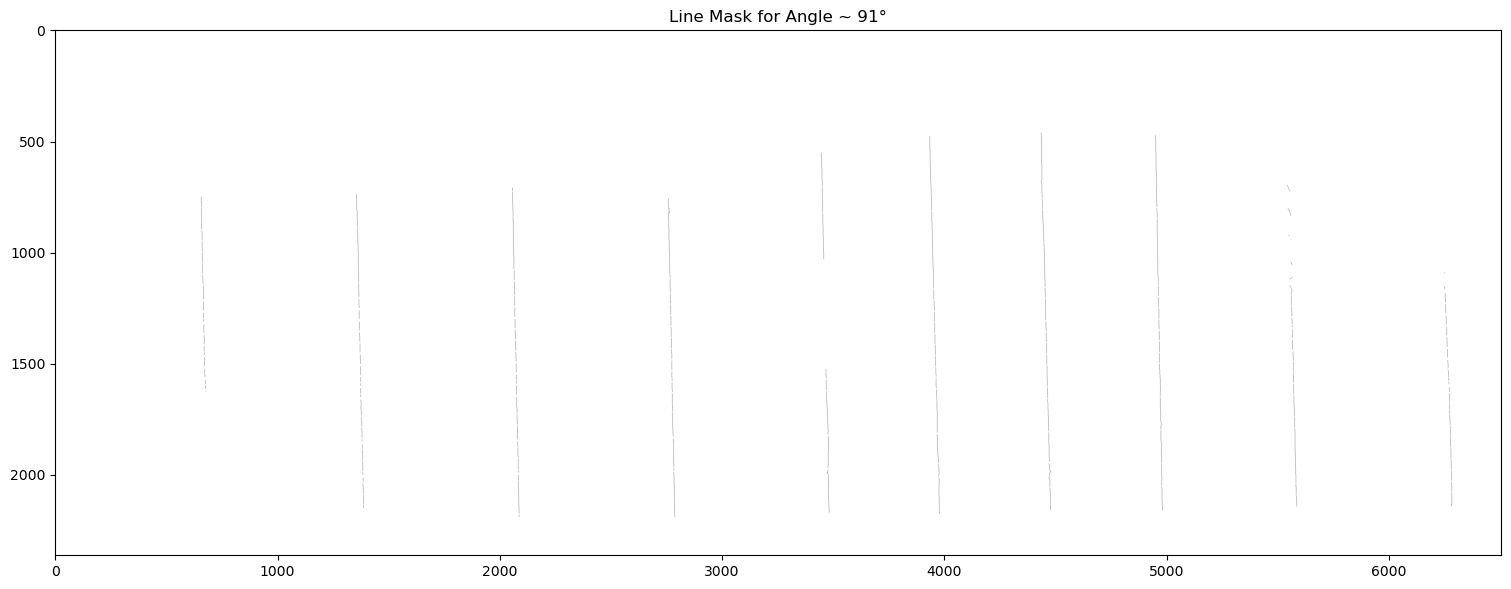

In [ ]:
selected_angles = [91]  # Angles of the line families to process
# selected_angles = [1, 91] 
for angle in selected_angles:
    line_mask = line_dicts[angle]

    plt.figure(figsize=(20, 15))
    plt.subplot(2, 1, 1)
    plt.imshow(1 - line_mask, cmap='gray')
    plt.title(f"Line Mask for Angle ~ {angle}°")

    # replace zero values in the line mask with NaN to prepare for depth assignment and spatial referencing
    line_mask = line_mask.astype(float)  # Convert to float to allow NaN values
    line_mask[line_mask == 0] = np.nan  # Replace 0 with NaN

    # line_mask_dict = deepcopy(bathy_data)
    # line_mask_dict['data'] = line_mask
    # line_mask_dict['filetype'] = 'raster'
    # line_mask_dict['metadata']['ndv_value'] = np.nan
    # # show_depth(line_mask_dict, title=f"Line Mask with Assigned Depths for Angle ~ {angle}°")

    # line_points = raster_to_scatter(line_mask_dict, remove_ndv=True)


    # Step 4: Rotate points so the detected lines align with the x-axis
    print(f"Rotating line points by {-angle + 90:.1f}° to align with x-axis...")
    target_angle = -angle + 90
    line_points = np.argwhere(~np.isnan(line_mask)).astype(int)  # Get coordinates of valid line pixels
    rotated_line_points, new_center = rotate_points(line_points, angle=target_angle, center=None)
    # print(f"Range of x-coordinates after rotation: {np.min(refined_cluster[:, 0])} to {np.max(refined_cluster[:, 0])}")

    # Update geotransform to reflect the rotation 
    old_gt = line_points["metadata"]["geotransform"]
    new_gt, new_shape = update_geotransform(rotated_line_points, old_gt[1], old_gt[5])

    # # Create new data dict for the rotated points with updated geotransform and shape
    rotated_data_dict = {
        "data": rotated_line_points,  # new grid dimensions
        "filetype": "points",
        "metadata": {**line_mask["metadata"], "geotransform": new_gt, "ndv_value": 0.0},
    }
    rotated_line_mask = scatter_to_raster(rotated_data_dict)

    # # Get coordinates of depth pixels
    # # depth_coords = np.argwhere(line_points['data'] != np.nan)

    # # Step 5: Run DBSCAN with the x-distance metric to separate individual survey
    # # lines. After rotation the lines should be well-separated along x, so a
    # # small eps (in metres) cleanly splits them into individual tracklines.
    # dbscan = DBSCAN(eps=10, min_samples=5, metric=x_distance)
    # subcluster_labels = dbscan.fit_predict(refined_cluster)
    # print(f"Unique subcluster labels detected: {np.unique(subcluster_labels)}")
    # # dbscan = DBSCAN(metric=x_distance)
    # # subcluster_labels = dbscan.fit_predict(depth_coords)

    # # # Create new raster layer for contigous trackline segments
    # # trackline_mask = np.full_like(line_points['data'], fill_value=0, dtype=bool)

    # # plt.figure(figsize=(15, 15))
    # # # plt.subplot(2, 1, 1)
    # # for label in np.unique(subcluster_labels):
    # #     plt.scatter(
    # #         refined_cluster[subcluster_labels == label, 0],
    # #         refined_cluster[subcluster_labels == label, 1],
    # #         s=2, label=f'Subcluster {label}',
    # #     )
    # # #set y-axis to upside down to match original raster orientation
    # # plt.legend()
    # # plt.title(f"Individual Tracklines (Subclusters) for Angle ~ {angle}°")
    # # plt.show()


    # # Create new raster layer for contigous trackline segments and 
    # # populate it based on the x-coordinates of the subclusters.
    # trackline_mask = np.zeros_like(line_mask).astype(np.uint8)
    # cluster_x_coords = {}
    # cluster_y_range = {}
    # for label in np.unique(subcluster_labels):
    #         x_mean = int(np.mean(refined_cluster[subcluster_labels == label][:, 0]))
    #         y_coords_min = int(np.min(refined_cluster[subcluster_labels == label][:, 1]))
    #         y_coords_max = int(np.max(refined_cluster[subcluster_labels == label][:, 1]))
    #         cluster_y_range[label] = (y_coords_min, y_coords_max)

    #         col_indices = np.round((x_mean - new_gt[0] - new_gt[1] / 2) / new_gt[1]).astype(int)
    #         row_indices_min = np.round((y_coords_min - new_gt[3] - new_gt[5] / 2) / new_gt[5]).astype(int)
    #         row_indices_max = np.round((y_coords_max - new_gt[3] - new_gt[5] / 2) / new_gt[5]).astype(int)
    #         cluster_x_coords[label] = col_indices
    #         # print(f"Subcluster {label}: x_mean={x_mean}, y_min={y_coords_min}, y_max={y_coords_max} -> col={col_indices}, row_min={row_indices_min}, row_max={row_indices_max}")
    #         print(f"Subcluster {label}: col={col_indices}, row_min={row_indices_min}, row_max={row_indices_max}")
    #         trackline_mask[row_indices_max:row_indices_min, col_indices] = 255

    # plt.figure(figsize=(15, 15))
    # plt.imshow(1 - trackline_mask.astype(bool), cmap='gray')
    # plt.title(f"Trackline Raster for Angle ~ {angle}°")
    # plt.show()

    # # Step 6: Sort clusters on increasing x_coordinates
    # cluster_order = np.array(sorted(cluster_x_coords.keys(), key=lambda x: cluster_x_coords[x])).astype(int)

    # trackline_depths = np.zeros_like(trackline_mask, dtype=float)
    # # # Step 1: Locate the pixel coordinates of the extracted line mask and the
    # # # valid (non-NDV) pixels in the original bathymetric raster.
    # destination_pts = np.argwhere(trackline_mask > 0).astype(int)
    
    # # Rotate original bathymetry points to match the orientation of the line mask for accurate nearest-neighbour lookup
    # bathy_pts = np.argwhere(bathy_data['data'] != bathy_data['metadata']['ndv_value']).astype(int)
    # source_values = bathy_data['data'][bathy_pts[:, 0], bathy_pts[:, 1]]
    # bathy_pts_rotated, _ = rotate_points(bathy_pts, angle=target_angle, center=new_center)
    # # source_pts = np.argwhere(bathy_data['data'] != bathy_data['metadata']['ndv_value']).astype(int)
    # source_pts = bathy_pts_rotated[:, :2]  # Assuming the third column contains the depth values

    # # # Step 2: Assign a real depth value to each line pixel via nearest-neighbour
    # # # lookup. Line mask pixels may not have a depth of their own (they were derived
    # # # from a thinned skeleton), so we borrow the closest valid sounding.
    # tree = cKDTree(source_pts)
    # _, nearest_source_idx = tree.query(destination_pts)
    # trackline_depths[destination_pts[:, 0], destination_pts[:, 1]] = source_values[nearest_source_idx]
    # trackline_depths[trackline_depths == 0] = np.nan  # Replace any remaining zeros with NaN for clarity

    # plt.figure(figsize=(15, 15))
    # plt.imshow(trackline_depths, cmap='terrain')
    # plt.title(f"Trackline Depths Assigned via Nearest-Neighbor Lookup for Angle ~ {angle}°")
    # plt.colorbar(label='Depth')
    # plt.show()
    # # # Step 3: Convert the line mask to a spatially referenced (x, y, depth)
    # # # point array using the original raster's geotransform.
    # # bathy_mask = np.full_like(bathy_data['data'], fill_value=np.nan)  # Start with a mask filled with the NDV
    # # bathy_mask[destination_pts[:, 0], destination_pts[:, 1]] = destination_values


    

In [16]:
# Step 7: For each pair of adjacent clusters in the sorted order, 
# combine their points and plot them together to visually confirm they belong to the same trackline family.
sorted_x_coords = np.sort(list(cluster_x_coords.values()))
cluster_pairs = np.array(list(zip(sorted_x_coords[:-1], sorted_x_coords[1:]))).astype(int)
print(f"Cluster pairs for comparison: {cluster_pairs[0]}")

Cluster pairs for comparison: [  2 703]


C:\Users\personal\AppData\Local\Temp\ipykernel_66608\1835587273.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


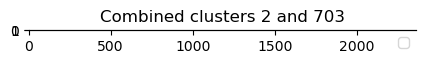

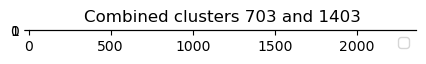

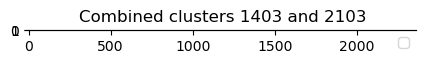

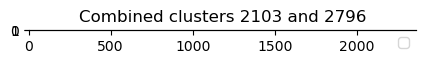

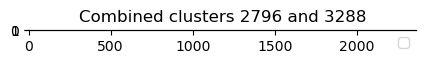

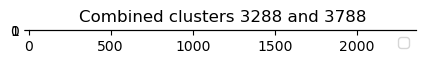

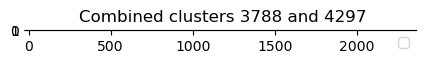

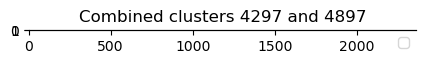

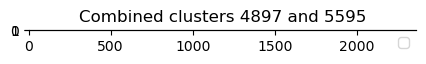

In [22]:

# Only compare adjacent clusters
for cluster_pair in cluster_pairs: 
    points1 = trackline_depths[:, cluster_pair[0]]
    points2 = trackline_depths[:, cluster_pair[1]]
    # label1, label2 = cluster_pair[0], cluster_pair[1]
    # points1 = refined_cluster[subcluster_labels == label1, :].copy()
    # points1[:, 0] = np.mean(points1[:, 0])

    # points2 = refined_cluster[subcluster_labels == label2, :].copy()
    # points2[:, 0] = np.mean(points2[:, 0])

    # Combine points
    combined_points = np.vstack([points1, points2])
    plt.figure(figsize=(5, 5))
    # plt.scatter(points1[:, 0], points1[:, 1], s=1, label=f'Subcluster {cluster_pair[0]}')
    # plt.scatter(points2[:, 0], points2[:, 1], s=1, label=f'Subcluster {cluster_pair[1]}')
    # plt.scatter(combined_points[:, 0], combined_points[:, 1], s=1, label=f'Combined')
    plt.imshow(combined_points, cmap='terrain')
    plt.legend()
    plt.title(f'Combined clusters {cluster_pair[0]} and {cluster_pair[1]}')
    plt.show()

    # # Compute raster coordinates of each cluster using the original geotransform
    # geotransform = bathy_data['metadata']['geotransform']
    # total_rotation = angle_correction + (90 - angle) # Add back the initial rotation and a small random rotation to avoid vertical lines
    # # total_rotation = 0
    # # cluster_data = rotate_points(combined_points, -total_rotation)
    # cluster_data = combined_points.copy()
    # cluster_dict = deepcopy(bathy_data)
    # cluster_dict['data'] = cluster_data
    # cluster_dict['metadata']['ndv_value'] = 0.0
    # cluster_dict['filetype'] = 'points'

    # show_depth(cluster_dict, cmap='jet')

    # # Rotate raster to align with vertical axis and plot
    # cluster_rasters = points_to_raster(cluster_data, base_raster=bathy_data)
    # show_depth(cluster_rasters, cmap='terrain')
    # vertical_raster = rotate(cluster_rasters['data'], angle=total_rotation, resize=True)

    # plt.figure(figsize=(5, 5))
    # plt.imshow(vertical_raster, cmap='jet')
    # plt.title(f'Rotated Raster of Combined Clusters {label1} and {label2}')
    # plt.legend()
    # plt.gca().invert_yaxis()  # Invert y-axis for correct orientation   
    # plt.show()



    



c:\Users\personal\miniconda3\envs\interpolation_uncertainty\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


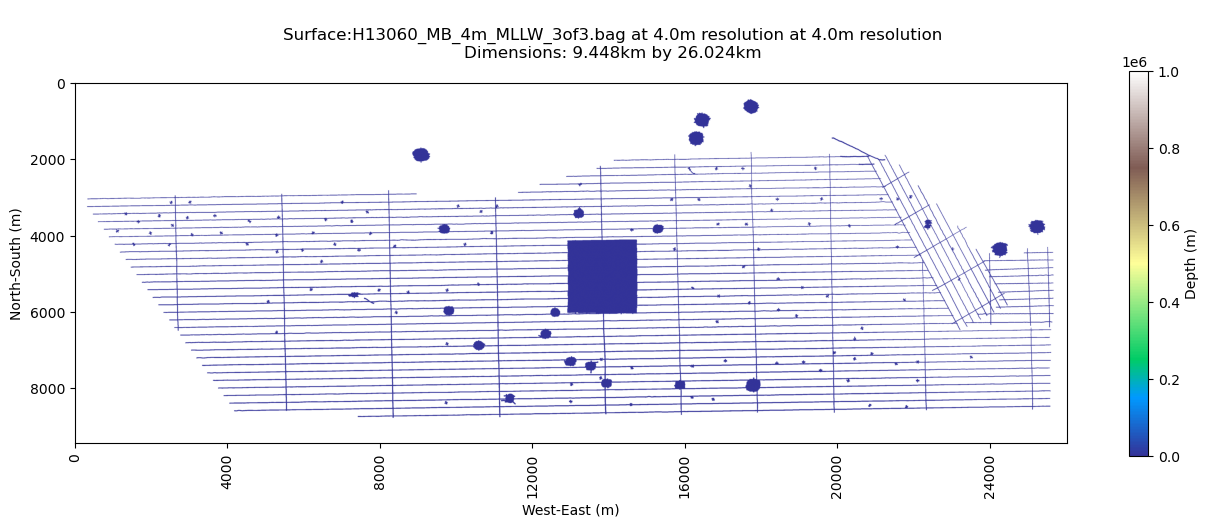

In [ ]:
trial_data = read_file(r"data/raster/H13060_MB_4m_MLLW_3of3.bag")
show_depth(trial_data)

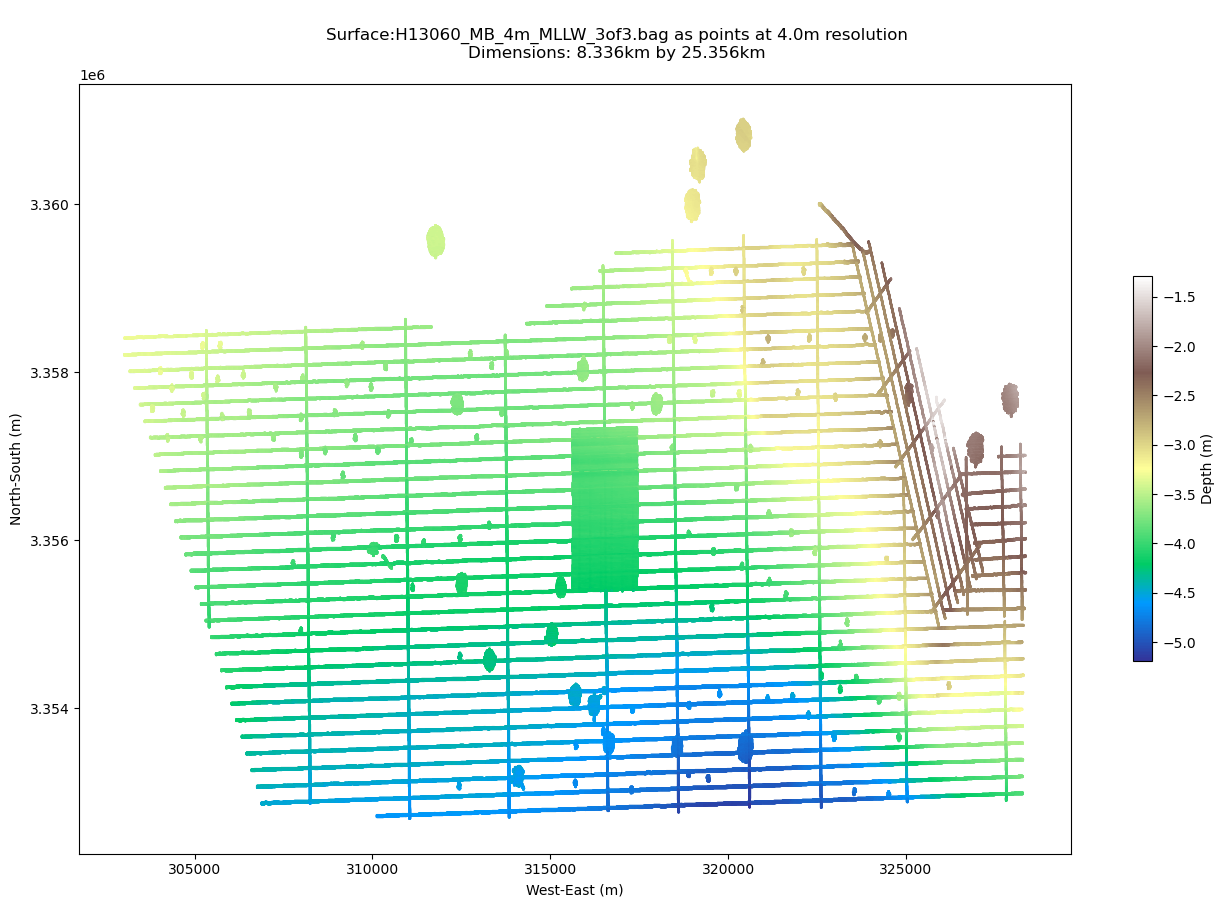

In [ ]:
scatter_trial = raster_to_points(trial_data, remove_ndv=True, plot_data=True)

In [ ]:
len(scatter_trial['data'])

1380966

Raster shape: 2362 x 6506, 
resolution: 4.0m, 
geotransform: (302698.0, 4.0, 0.0, 3361470.0, 0.0, -4.0)
Spatial coordinates range: 
x [303020.0, 328376.0], 
y [3352684.0, 3361020.0]
Computed pixel indices range: 
row [112, 2196], 
col [80, 6419]


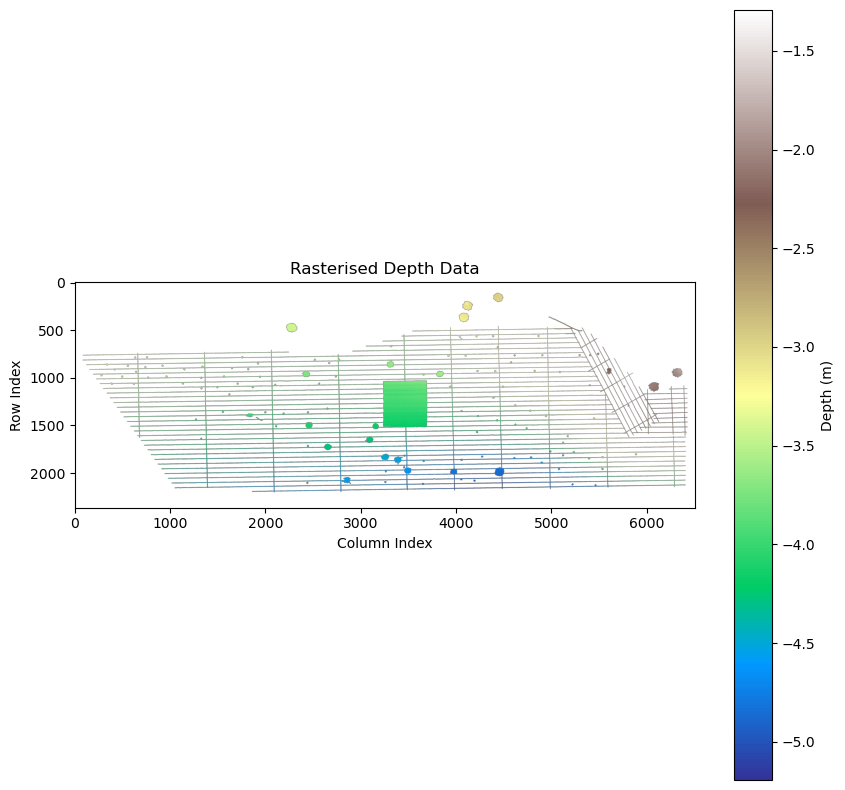

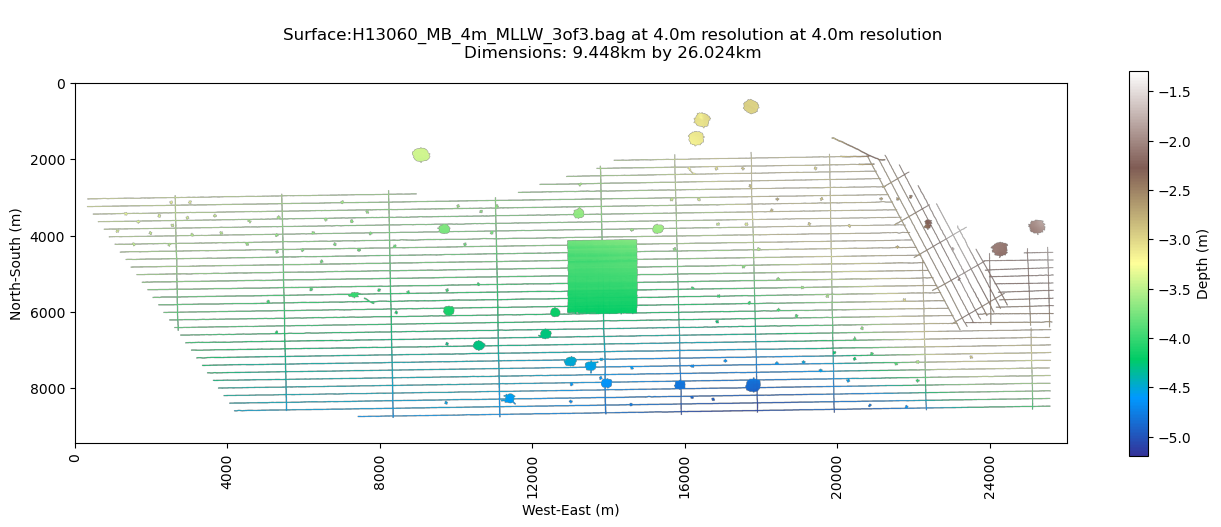

In [ ]:
raster_trial = points_to_raster(scatter_trial['data'], base_raster=trial_data, plot_data=True)

In [ ]:
                # label_coords = depth_coords[subcluster_labels == label]
            # x_mean = int(np.mean(label_coords[:, 1]))
            # cluster_x_coords[label] = x_mean
            # y_coords_min = np.min(label_coords[:, 0])
            # y_coords_max = np.max(label_coords[:, 0])
            # trackline_mask[y_coords_min:y_coords_max, cluster_x_coords[label]] = True

            # Convert back to original raster coordinates for indexing
            # x_coords_raster = new_gt[0] + x_mean * new_gt[1] + new_gt[1] / 2
            # y_coords_raster_min = new_gt[3] + y_coords_min * new_gt[5] + new_gt[5] / 2
            # y_coords_raster_max = new_gt[3] + y_coords_max * new_gt[5] + new_gt[5] / 2

            # row_indices = np.round((x_mean - new_gt[3] - new_gt[5] / 2) / new_gt[3]).astype(int)
            # col_indices_min = np.round((y_coords_min - new_gt[0] - new_gt[1] / 2) / new_gt[1]).astype(int)
            # col_indices_max = np.round((y_coords_max - new_gt[0] - new_gt[1] / 2) / new_gt[1]).astype(int)



# line_raster = 1 - (line_points['data'] != np.nan)
    # line_raster = dilation(line_raster.astype(bool), disk(radius=10)).astype(bool)
    # plt.figure(figsize=(15, 15))
    # plt.imshow(line_points['data'], cmap='jet')
    # plt.title(f"After rotation")
    # # plt.colorbar(label='Depth')
    # plt.show()


    # show_depth(line_points, 
    #            title=f"Refined the rotation with angle: {target_angle}°")

    # # Refine the rotation using DBSCAN subclustering + PCA on the largest clusters.
    # refined_cluster, angle_correction = refine_cluster_rotation(rotated_line_points) # ????

    # plt.figure(figsize=(15, 15))
    # plt.scatter(refined_cluster[:, 0], refined_cluster[:, 1], s=10)
    # plt.title(f"Refined Cluster after Rotation for Angle ~ {angle}° (Correction: {angle_correction:.2f}°)")
    # plt.axis('equal')
    # plt.show()



    # # Step 6: For each subcluster, fit a line and compute its equation using RANSAC regression. 
    # # This gives us a parametric representation of each trackline. 
    # for label in np.unique(subcluster_labels):
    #     if label == -1:
    #         continue  # Skip noise points

    #     subcluster_pts = refined_cluster[subcluster_labels == label][:, :2]
    #     subcluster_depths = refined_cluster[subcluster_labels == label][:, 2]

    #     ransac = RANSACRegressor(residual_threshold=5, min_samples=10)
    #     ransac.fit(subcluster_pts[:, 0].reshape(-1, 1), subcluster_pts[:, 1])

    #     slope = ransac.estimator_.coef_[0]
    #     intercept = ransac.estimator_.intercept_
        # print(f"Subcluster {label}: y = {slope:.4f}x + {intercept:.2f}")

In [ ]:
def compute_energy_elias(data: np.ndarray,
                         resolution: int,
                         method: str,
                         window_values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Compute the spectral energy of depth profiles using a specified FFT method.

    Applies a real FFT along the column axis of ``data`` and scales the result
    according to ``method``. Each row of ``data`` is treated as an independent
    depth profile (e.g., a single across-track strip).

    Parameters
    ----------
    data : np.ndarray
        2D array of shape ``(n_strips, n_samples)`` containing depth values.
        Each row is one depth profile.
    resolution : int
        Spatial sampling interval in metres. Used to convert FFT bin indices
        to physical frequencies (cycles per metre).
    method : str
        Spectral scaling method. One of:

        - ``'amplitude'`` — amplitude spectral density (ASD); scales by
          ``sqrt(resolution) / sqrt(sum(window^2))``.
        - ``'psd'`` — one-sided power spectral density.
        - ``'psd_n'`` — normalised PSD (currently identical to ``'psd'``;
          reserved for future per-bin normalisation).
        - ``'psd_lf'`` — low-frequency PSD variant (currently identical to
          ``'psd'``; reserved for frequency-band filtering).
        - ``'psd_df'`` — differential-frequency PSD variant (currently
          identical to ``'psd'``; reserved for differential scaling).
        - ``'spectrum'`` — amplitude spectrum (currently identical to
          ``'psd'``; reserved for direct spectral visualisation).
    window_values : np.ndarray
        1D array of length ``n_samples`` containing window coefficients
        (e.g., a Hann window). Used only in the normalisation denominator
        ``sqrt(sum(window^2))``; the window is **not** applied to the data
        in the time domain inside this function.

    Returns
    -------
    energy : np.ndarray
        2D array of shape ``(n_strips, n_freqs)`` containing spectral energy
        estimates. The Nyquist bin is dropped (last column excluded).
    rfft_frequencies : np.ndarray
        1D array of length ``n_freqs`` with the corresponding spatial
        frequencies in cycles per metre.
    """
    rfft_values = np.abs(np.fft.rfft(data, axis=1))
    _, num_cols = rfft_values.shape
    rfft_frequencies = np.fft.rfftfreq(data.shape[1], d=resolution)

    if method == "amplitude":
        cden = np.sqrt(np.sum(window_values ** 2))
        energy = np.sqrt(resolution) * rfft_values / cden

        if num_cols % 2 == 0:
            energy[:, 1:-1] = energy[:, 1:-1] * 2
        else:
            energy[:, 1:] = energy[:, 1:] * 2

        energy = energy[:, :-1]
        rfft_frequencies = rfft_frequencies[:-1]

    elif method in ("psd", "psd_n", "psd_lf", "psd_df", "spectrum"):
        cden = np.sqrt(np.sum(window_values ** 2))
        energy = resolution * (np.abs(rfft_values / cden) ** 2)

        if num_cols % 2 == 0:  # even length → Nyquist bin exists
            energy[:, 1:-1] *= 2
        else:                  # odd length → no Nyquist bin
            energy[:, 1:] *= 2

        energy = energy[:, :-1]
        rfft_frequencies = rfft_frequencies[:-1]

    else:
        raise ValueError(
            f"Unknown FFT method: '{method}'. "
            f"Valid options: 'amplitude', 'psd', 'psd_n', 'psd_lf', 'psd_df', 'spectrum'."
        )

    return energy, rfft_frequencies

In [ ]:
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])